<a href="https://colab.research.google.com/github/guadalupesbel-commits/EstadisticaVerano2026/blob/main/Problema05_U4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5. En una empresa de manufactura se propone un tratamiento para reducir el porcentaje de productos defectuosos. Para validar esta propuesta se diseñó un experimento en el que se producía con o sin la propuesta de mejora. Cada corrida experimental consistió en producir un lote y la variable de respuesta es el porcentaje de producto defectuoso. Se hicieron 25 réplicas para cada tratamiento. Los datos obtenidos se muestran a continuación:

| Tratamiento     | Porcentaje de producto defectuoso                                     |
|-----------------|----------------------------------------------------------------------|
| Con tratam.     | 5.3, 4.0, 4.0, 4.0, 2.6, 2.1, 5.1, 4.1, 4.1, 3.2, 5.1, 2.2, 4.1     |
| Sin tratam.     | 8.0, 13.2, 7.2, 8.2, 9.1, 6.7, 12.6, 16.3, 9.2, 6.4, 7.2, 17.2, 12.3 |


In [ ]:
import pandas as pd
from io import StringIO

datos='''
tratamiento,productos
C/T,5.3
S/T,8.0
C/T,4.0
S/T,13.2
C/T,4.0
S/T,7.2
C/T,4.0
S/T,8.2
C/T,2.6
S/T,9.1
C/T,2.1
S/T,6.7
C/T,5.1
S/T,12.6
C/T,4.1
S/T,16.3
C/T,4.1
S/T,9.2
C/T,3.2
S/T,6.4
C/T,5.1
S/T,7.2
C/T,2.2
S/T,17.2
C/T,4.1
S/T,12.3
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,tratamiento,productos
0,C/T,5.3
1,S/T,8.0
2,C/T,4.0
3,S/T,13.2
4,C/T,4.0
5,S/T,7.2
6,C/T,4.0
7,S/T,8.2
8,C/T,2.6
9,S/T,9.1


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_1 = mu_2 = mu_3
#H1: al menos una media es diferente

modelo = ols('productos~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),269.4496,1.0,37.1028,0.0
Residual,174.2938,24.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.08240142335255941


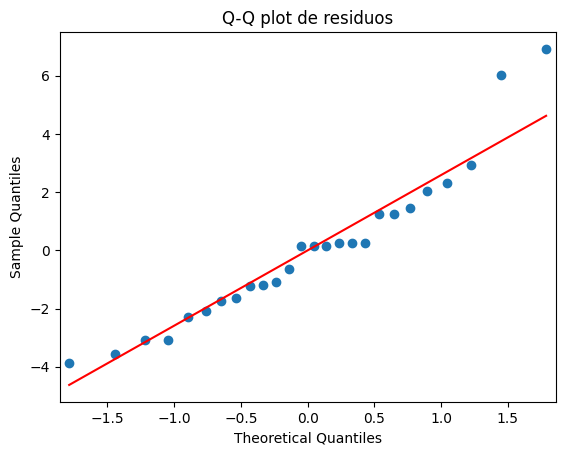

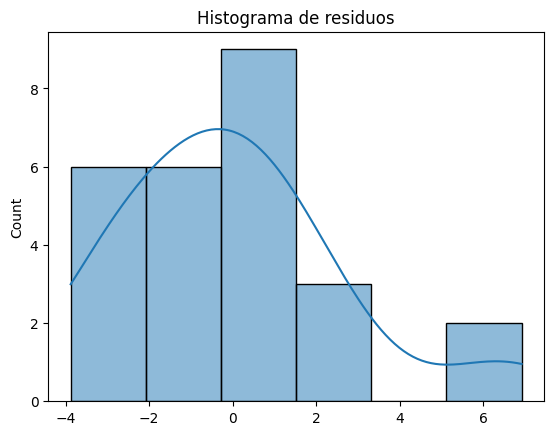

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tratamiento'] == 'C/T']['productos']
grupo_B = df[df['tratamiento'] == 'S/T']['productos']


stat, p = levene(grupo_A, grupo_B)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 8.7144
p-valor: 0.0070


Lambda óptimo: -0.05387225396368365


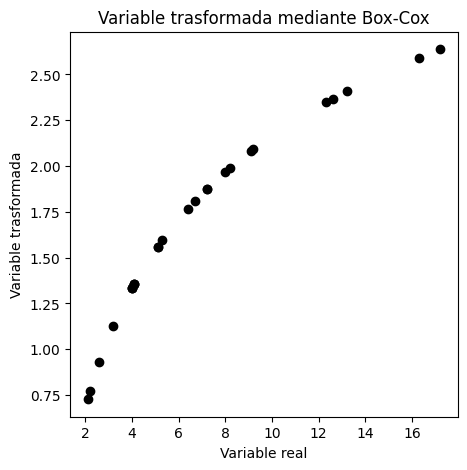

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["productos_boxcox"], lambda_opt = boxcox(df["productos"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["productos"], df["productos_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('productos_boxcox ~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),5.0403,1.0,58.8438,0.0
Residual,2.0557,24.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.5855089577225056


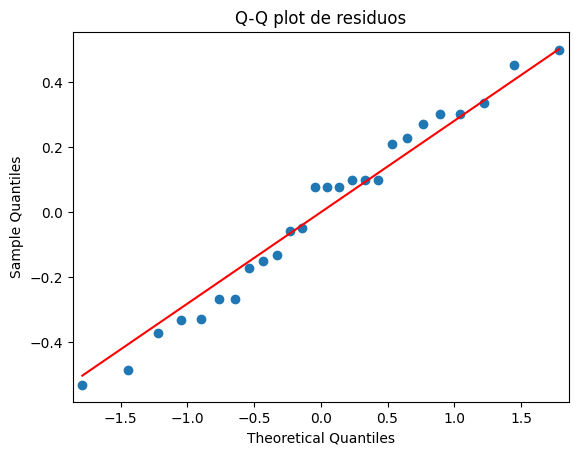

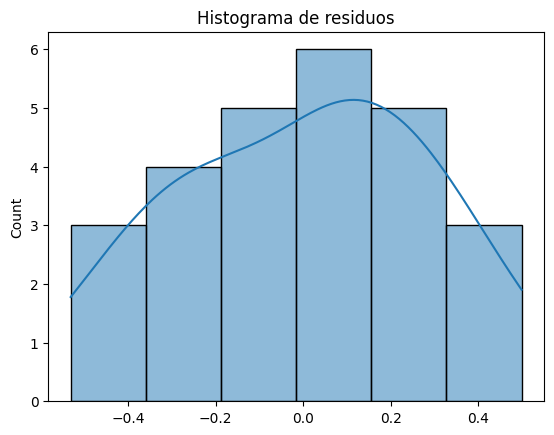

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tratamiento'] == 'C/T']['productos_boxcox']
grupo_B = df[df['tratamiento'] == 'S/T']['productos_boxcox']

stat, p = levene(grupo_A, grupo_B)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.3797
p-valor: 0.5436


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   C/T    S/T   0.8806   0.0 0.6437 1.1175   True
-------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

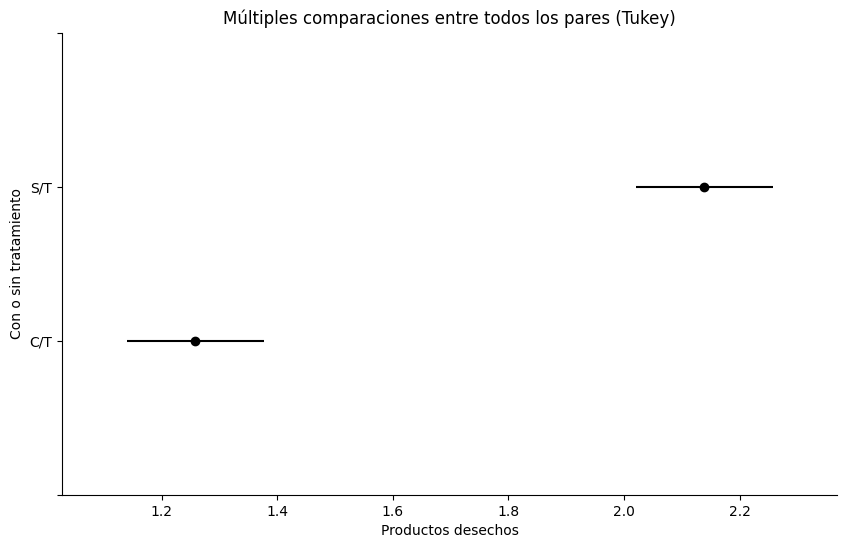

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['productos_boxcox'], # Variable de respuesta
    groups=df['tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Con o sin tratamiento", xlabel="Productos desechos")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["tratamiento"]).mean()["productos"]

,productos
tratamiento,
C/T,3.838462
S/T,10.276923


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(tratamiento)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.710


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["tratamiento"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.7103
f de Cohen = 1.5658
Potencia de la prueba = 1.0000


Conclusión:

Con los metodos aplicados de anova, proseguimos con el test de shapiro y nos dio un valor de $0.0824$ que indica que si existe normalidad. Despues test de Levene el cual nos dio un resultado de $0.007$ lo cual nos indica que no hubo homoscedasticidad.

Así que aplicamos el metodo de boxcox lo implica volver a hacer todo nuevamente pero tomando en cuenta los nuevos valores del boxcox, de lo cual de shapiro nos dio un resultado de $0.5855$ lo cual indica que hay normalidad y del test de levene tuvimos un total de 0.543 lo cual nos indica que si hubo homocedasticidad.

En el test de tukey podemos ver de manera gráfica que con tratamiento hay 1% producto desecho pero si no hacemos tratamiento nos da 2% productos desechos y lo que queremos es minimizar los productos. Ademas que en promedio nos da $3.83%$ de productos desechos con tratamiento y sin tratamiento nos da 10.27% asi que lo recomendable es hacer el tratamiento para minimizar los productos desechos.